## Imports & Global Settings

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

## Define Experiment Metadata

In [35]:
LOG_DIR = "../experiments/logs"

losses = ["vanilla", "lsgan", "wgan", "wgan_gp"]
splits = [1000, 5000, 10000, 25000]

def log_path(loss, split):
    return os.path.join(LOG_DIR, f"dcgan_{loss}_{split}.csv")

## Load All Logs into a Single DataFrame

In [37]:
all_logs = []

for loss in losses:
    for split in splits:
        path = log_path(loss, split)
        if os.path.exists(path):
            df = pd.read_csv(path)
            df["loss_type"] = loss
            df["data_size"] = split
            all_logs.append(df)

logs_df = pd.concat(all_logs, ignore_index=True)
logs_df.head()

,epoch,d_loss,g_loss,epoch_time,params_G(M),params_D(M),loss_type,data_size
0,1,0.825042,7.393288,11.172182,3.576704,2.765568,vanilla,1000
1,2,0.396593,9.665288,10.996530,3.576704,2.765568,vanilla,1000
2,3,0.572213,6.801641,7.285169,3.576704,2.765568,vanilla,1000
3,4,0.774729,3.586730,11.593680,3.576704,2.765568,vanilla,1000
4,5,0.560886,4.317598,17.481916,3.576704,2.765568,vanilla,1000


## Sanity Check: Available Experiments

In [39]:
logs_df.groupby(["loss_type", "data_size"]).size()

loss_type  data_size
lsgan      1000         50
           5000         50
           10000        50
           25000        50
vanilla    1000         50
           5000         50
           10000        50
           25000        50
wgan       1000         50
           5000         50
           10000        50
           25000        50
wgan_gp    1000         50
           5000         50
           10000        50
           25000        50
dtype: int64

# **VISUAL ANALYSIS**

## Generator Loss Curves (Per Split)

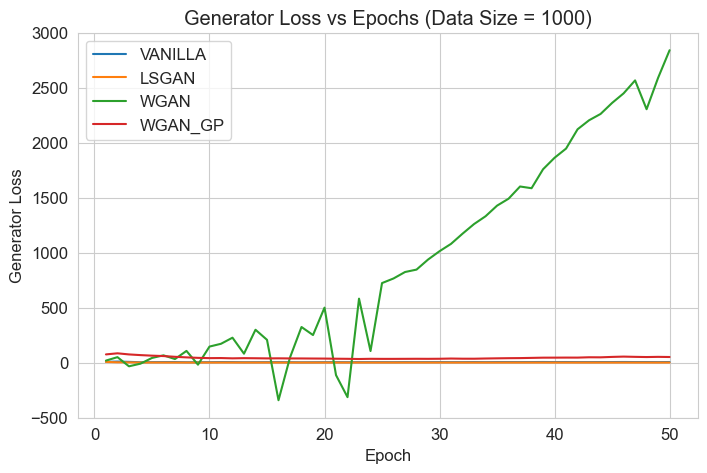

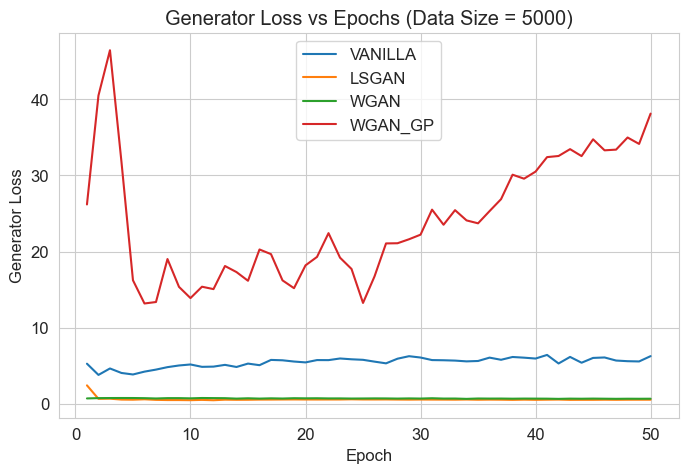

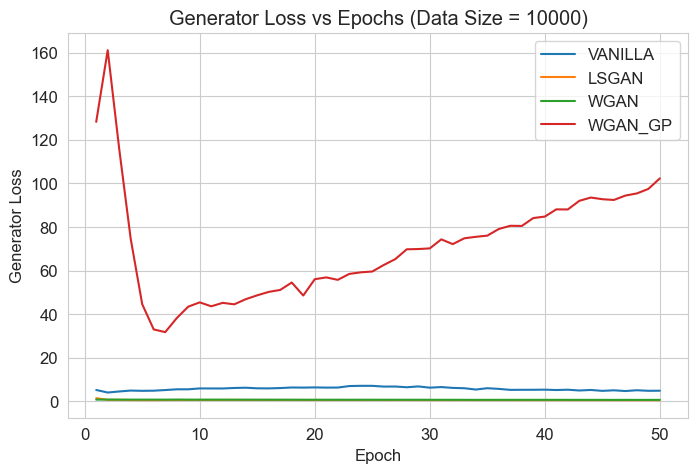

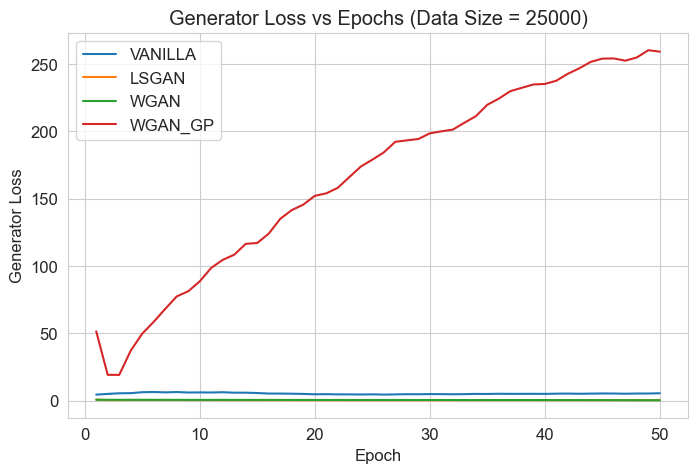

In [42]:
for split in splits:
    plt.figure()
    for loss in losses:
        subset = logs_df[
            (logs_df["loss_type"] == loss) &
            (logs_df["data_size"] == split)
        ]
        if not subset.empty:
            plt.plot(subset["epoch"], subset["g_loss"], label=loss.upper())

    plt.title(f"Generator Loss vs Epochs (Data Size = {split})")
    plt.xlabel("Epoch")
    plt.ylabel("Generator Loss")
    plt.legend()
    plt.show()

## Discriminator / Critic Loss Curves

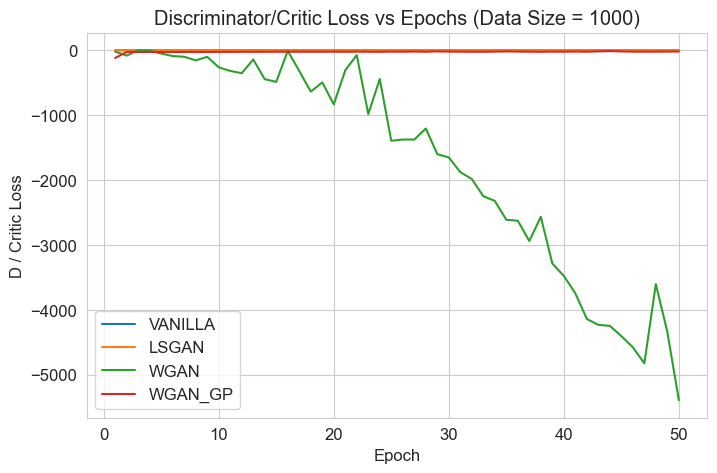

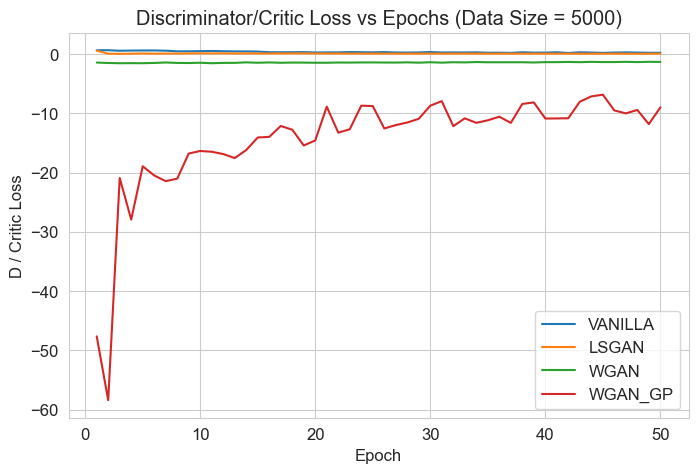

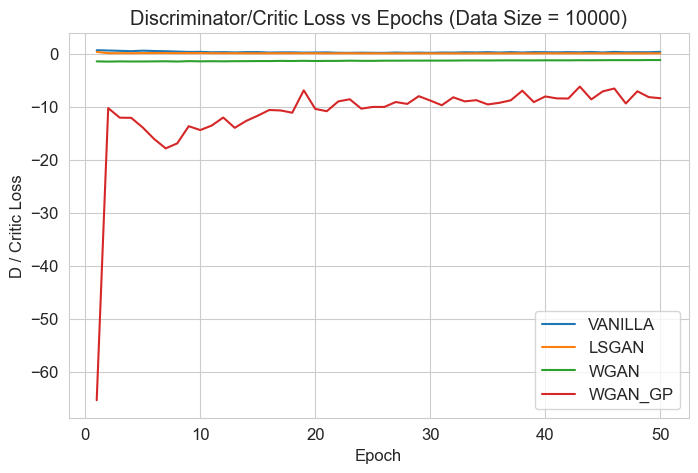

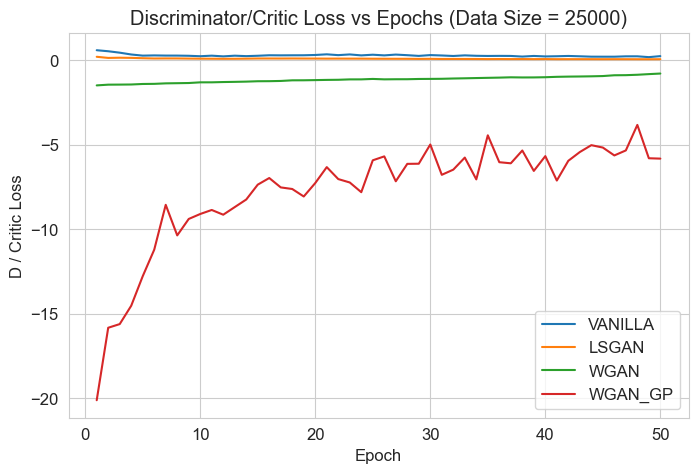

In [44]:
for split in splits:
    plt.figure()
    for loss in losses:
        subset = logs_df[
            (logs_df["loss_type"] == loss) &
            (logs_df["data_size"] == split)
        ]
        if not subset.empty:
            plt.plot(subset["epoch"], subset["d_loss"], label=loss.upper())

    plt.title(f"Discriminator/Critic Loss vs Epochs (Data Size = {split})")
    plt.xlabel("Epoch")
    plt.ylabel("D / Critic Loss")
    plt.legend()
    plt.show()

# STABILITY ANALYSIS

## Loss Variance (Training Stability Metric)

In [47]:
stability = []

for loss in losses:
    for split in splits:
        subset = logs_df[
            (logs_df["loss_type"] == loss) &
            (logs_df["data_size"] == split)
        ]
        if not subset.empty:
            stability.append({
                "loss_type": loss,
                "data_size": split,
                "g_loss_std": subset["g_loss"].std(),
                "d_loss_std": subset["d_loss"].std()
            })

stability_df = pd.DataFrame(stability)
stability_df

,loss_type,data_size,g_loss_std,d_loss_std
0,vanilla,1000,1.085834,0.130201
1,vanilla,5000,0.627684,0.131449
2,vanilla,10000,0.740472,0.117556
3,vanilla,25000,0.534028,0.073185
4,lsgan,1000,0.894713,0.188801
5,lsgan,5000,0.267530,0.073696
6,lsgan,10000,0.129863,0.041247
7,lsgan,25000,0.076122,0.027213
8,wgan,1000,927.369847,1651.626189
9,wgan,5000,0.031316,0.064145


## Stability Comparison Plot

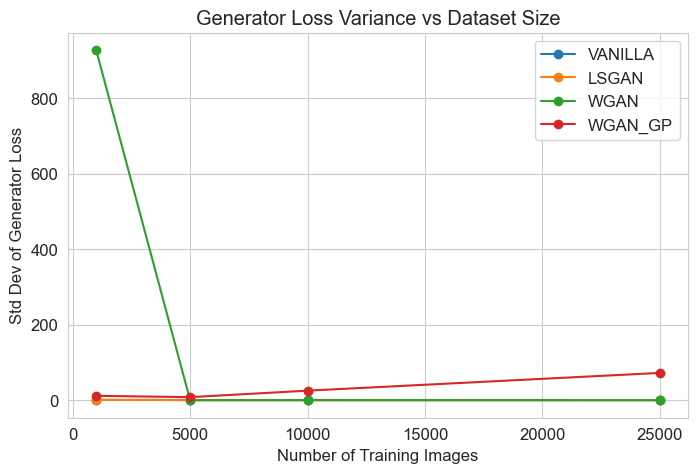

In [49]:
plt.figure()
for loss in losses:
    subset = stability_df[stability_df["loss_type"] == loss]
    plt.plot(subset["data_size"], subset["g_loss_std"], marker="o", label=loss.upper())

plt.title("Generator Loss Variance vs Dataset Size")
plt.xlabel("Number of Training Images")
plt.ylabel("Std Dev of Generator Loss")
plt.legend()
plt.show()

# COMPUTATIONAL COST ANALYSIS

## Epoch Time Comparison

In [52]:
time_stats = (
    logs_df
    .groupby(["loss_type", "data_size"])["epoch_time"]
    .mean()
    .reset_index()
)

time_stats

,loss_type,data_size,epoch_time
0,lsgan,1000,16.944207
1,lsgan,5000,32.243577
2,lsgan,10000,24.557198
3,lsgan,25000,26.594125
4,vanilla,1000,15.309961
5,vanilla,5000,28.305626
6,vanilla,10000,15.853332
7,vanilla,25000,26.431078
8,wgan,1000,15.969554
9,wgan,5000,49.090875


## Training Time Plot

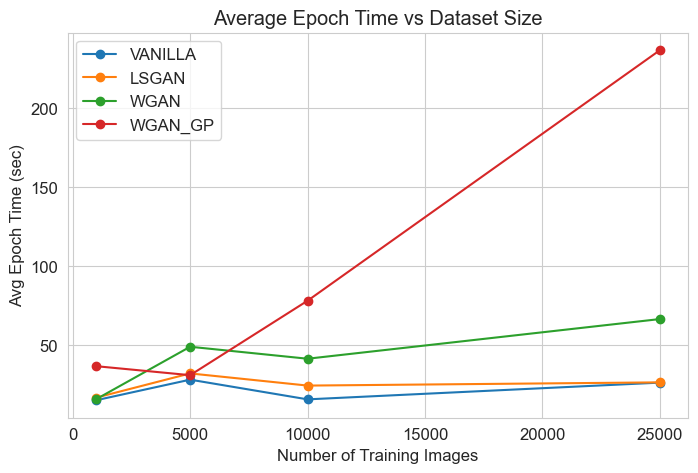

In [54]:
plt.figure()
for loss in losses:
    subset = time_stats[time_stats["loss_type"] == loss]
    plt.plot(subset["data_size"], subset["epoch_time"], marker="o", label=loss.upper())

plt.title("Average Epoch Time vs Dataset Size")
plt.xlabel("Number of Training Images")
plt.ylabel("Avg Epoch Time (sec)")
plt.legend()
plt.show()

# SUMMARY TABLE

## Final Summary Table

In [70]:
summary = stability_df.merge(
    time_stats,
    on=["loss_type", "data_size"],
    how="left"
)

summary = summary.rename(columns={
    "epoch_time": "avg_epoch_time_sec"
})

summary

,loss_type,data_size,g_loss_std,d_loss_std,avg_epoch_time_sec
0,vanilla,1000,1.085834,0.130201,15.309961
1,vanilla,5000,0.627684,0.131449,28.305626
2,vanilla,10000,0.740472,0.117556,15.853332
3,vanilla,25000,0.534028,0.073185,26.431078
4,lsgan,1000,0.894713,0.188801,16.944207
5,lsgan,5000,0.267530,0.073696,32.243577
6,lsgan,10000,0.129863,0.041247,24.557198
7,lsgan,25000,0.076122,0.027213,26.594125
8,wgan,1000,927.369847,1651.626189,15.969554
9,wgan,5000,0.031316,0.064145,49.090875


In [76]:
SAVE_DIR = "../experiments/plots"
os.makedirs(SAVE_DIR, exist_ok=True)

for split in splits:
    plt.figure()
    for loss in losses:
        subset = logs_df[
            (logs_df["loss_type"] == loss) &
            (logs_df["data_size"] == split)
        ]
        if not subset.empty:
            plt.plot(subset["epoch"], subset["g_loss"], label=loss.upper())

    plt.title(f"Generator Loss (Data Size = {split})")
    plt.xlabel("Epoch")
    plt.ylabel("Generator Loss")
    plt.legend()
    plt.savefig(f"{SAVE_DIR}/g_loss_{split}.png", dpi=300, bbox_inches="tight")
    plt.close()

In [78]:
SAVE_DIR = "../experiments/plots"
os.makedirs(SAVE_DIR, exist_ok=True)

for split in splits:
    plt.figure()
    for loss in losses:
        subset = logs_df[
            (logs_df["loss_type"] == loss) &
            (logs_df["data_size"] == split)
        ]
        if not subset.empty:
            plt.plot(subset["epoch"], subset["d_loss"], label=loss.upper())

    plt.title(f"Discriminator Loss (Data Size = {split})")
    plt.xlabel("Epoch")
    plt.ylabel("Generator Loss")
    plt.legend()
    plt.savefig(f"{SAVE_DIR}/d_loss_{split}.png", dpi=300, bbox_inches="tight")
    plt.close()